# Neural Network Surrogate for American Option Pricing

This notebook builds a neural network that learns to price American put options, using the **Bjerksund-Stensland (2002)** analytical approximation as the ground-truth teacher.

## The idea in one sentence
American options have no simple closed-form price because they can be exercised early. The accurate method (Longstaff-Schwartz Monte Carlo) is slow (~1 second per price). We train a small neural network to approximate the pricing function so it can evaluate thousands of options in microseconds.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats.qmc import Sobol
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time

np.random.seed(0)
torch.manual_seed(0)

## What Bjerksund-Stensland does
BS02 is an **analytical approximation**: it approximates the optimal early-exercise boundary with a simple functional form, then prices the option given that boundary. It's accurate to a few cents and runs in microseconds.

It uses a **put-call transformation**: an American put on $S$ with strike $K$ equals an American call on $K$ with strike $S$, swapping $r \leftrightarrow q$. So the code implements the call formula and calls it with swapped arguments.

In [2]:
def _phi(S, T, gamma, H, I, r, b, sigma):
    """Helper integral used throughout the BS02 formula.

    phi = e^lambda * S^gamma * [ N(d) - (I/S)^kappa * N(d - 2 ln(I/S)/(sigma sqrt(T))) ]

    It's a generalized Black-Scholes integral with a barrier-reflection term.
    Every term in the price is a linear combination of these phi calls.
    """
    lam = (-r + gamma * b + 0.5 * gamma * (gamma - 1) * sigma**2) * T
    d = -(np.log(S / H) + (b + (gamma - 0.5) * sigma**2) * T) / (sigma * np.sqrt(T))
    kappa = 2 * b / (sigma**2) + (2 * gamma - 1)
    return (np.exp(lam) * S**gamma
            * (norm.cdf(d)
               - (I / S)**kappa * norm.cdf(d - 2 * np.log(I / S) / (sigma * np.sqrt(T)))))


def bs_european_put(S, K, T, r, sigma, q=0.0):
    """Black-Scholes European put. Lower bound for the American put."""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1))


def _bs_european_call(S, K, T, r, sigma, q):
    b = r - q
    d1 = (np.log(S / K) + (b + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(S * np.exp((b - r) * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))

### The core call-pricing routine

The algorithm:
1. If `b >= r` (no dividends), early exercise is never optimal → use the European call formula.
2. Otherwise, compute the critical exponent $\beta$ from the perpetual-option quadratic.
3. Approximate the early-exercise boundary by interpolating between the boundary at expiry ($B_0$) and the perpetual boundary ($B_\infty$).
4. Split the time interval at the golden-ratio point $t_1 = \tfrac{1}{2}(\sqrt5 - 1)T$.
5. Assemble the price from ~12 evaluations of `_phi`.

In [3]:
def _american_call_bs02(S, K, T, r, sigma, q):
    """Bjerksund-Stensland (2002) American call approximation."""
    b = r - q
    if b >= r:
        return _bs_european_call(S, K, T, r, sigma, q)

    beta = (0.5 - b / sigma**2) + np.sqrt((b / sigma**2 - 0.5)**2 + 2 * r / sigma**2)
    B_inf = beta / (beta - 1) * K
    B_0 = max(K, r / (r - b) * K) if abs(r - b) > 1e-10 else K
    h_T = -(b * T + 2 * sigma * np.sqrt(T)) * B_0 / (B_inf - B_0)
    I = B_0 + (B_inf - B_0) * (1 - np.exp(h_T))

    if S >= I:
        return S - K

    t1 = 0.5 * (np.sqrt(5) - 1) * T
    beta1 = (0.5 - b / sigma**2) + np.sqrt((b / sigma**2 - 0.5)**2
                                           + 2 * r / (sigma**2 * (1 - np.exp(-r * t1))))
    B_t1_inf = beta1 / (beta1 - 1) * K
    B_t1_0 = max(K, r / (r - b) * K) if abs(r - b) > 1e-10 else K
    h_t1 = -(b * t1 + 2 * sigma * np.sqrt(t1)) * B_t1_0 / (B_t1_inf - B_t1_0)
    I_t1 = B_t1_0 + (B_t1_inf - B_t1_0) * (1 - np.exp(h_t1))

    if S >= I_t1:
        alpha1 = (I_t1 - K) * I_t1 ** (-beta)
        return (alpha1 * S**beta
                - alpha1 * _phi(S, t1, beta, I_t1, I_t1, r, b, sigma)
                + _phi(S, t1, 1, I_t1, I_t1, r, b, sigma)
                - _phi(S, t1, 1, K, I_t1, r, b, sigma)
                - K * _phi(S, t1, 0, I_t1, I_t1, r, b, sigma)
                + K * _phi(S, t1, 0, K, I_t1, r, b, sigma))
    else:
        alpha2 = (I - K) * I ** (-beta)
        alpha1 = (I_t1 - K) * I_t1 ** (-beta)
        return (alpha2 * S**beta
                - alpha2 * _phi(S, T, beta, I, I_t1, r, b, sigma)
                + _phi(S, T, 1, I, I_t1, r, b, sigma)
                - _phi(S, T, 1, K, I_t1, r, b, sigma)
                - K * _phi(S, T, 0, I, I_t1, r, b, sigma)
                + K * _phi(S, T, 0, K, I_t1, r, b, sigma)
                + alpha1 * _phi(S, T, beta, I_t1, I_t1, r, b, sigma)
                - alpha1 * _phi(S, t1, beta, I_t1, I_t1, r, b, sigma)
                + _phi(S, t1, 1, I_t1, I_t1, r, b, sigma)
                - _phi(S, T, 1, I_t1, I_t1, r, b, sigma)
                + K * _phi(S, T, 0, I_t1, I_t1, r, b, sigma)
                - K * _phi(S, t1, 0, I_t1, I_t1, r, b, sigma))


def american_put_bs02(S, K, T, r, sigma, q=0.0):
    if T <= 0:
        return max(K - S, 0.0)
    if sigma <= 0:
        return max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0)
    sigma = min(sigma, 2.0)
    T = min(T, 10.0)
    result = _american_call_bs02(K, S, T, q, sigma, r)
    if not np.isfinite(result) or result < 0:
        return max(bs_european_put(S, K, T, r, sigma, q), 0.0)
    return result

### Sanity check: the American put is worth more than the European put

The difference is the **early-exercise premium** — the value of being allowed to exercise before expiry. It must be positive.

In [ ]:
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
am = american_put_bs02(S, K, T, r, sigma)
eu = bs_european_put(S, K, T, r, sigma)
print(f"At-the-money put (S={S}, K={K}, T={T}, r={r}, sigma={sigma})")
print(f"  European put:        {eu:.4f}")
print(f"  American put (BS02): {am:.4f}")
print(f"  Early-exercise premium: {am - eu:.4f}  (must be >= 0)")

---
# 2. Data Generation

To train the network we need a labeled table: `(parameters) -> price`. Two steps:
1. **Choose parameters** — sample the 5D space with a Sobol quasi-random sequence (even coverage, no clumps or gaps).
2. **Compute prices** — call Bjerksund-Stensland on each parameter set to get the label.

### Key design choices
- **Sobol over random sampling:** fills the space evenly, so the network never has to extrapolate into an uncovered region.
- **Moneyness normalization:** we fix `K = 100` and sample `moneyness = S/K`. A \$95 stock with \$100 strike behaves like a \$9.50 stock with \$10 strike, so learning in terms of the ratio gives a price-level-independent function.
- **Normalize price by K:** keeps targets in a small range (~0 to 1), which helps training.

In [4]:
PARAM_RANGES = {
    "moneyness": (0.7, 1.3),   # S/K
    "T":         (0.1, 3.0),   # years to expiry
    "r":         (0.01, 0.10), # risk-free rate
    "sigma":     (0.10, 0.60), # volatility
    "q":         (0.00, 0.05), # dividend yield
}


def generate_dataset(n_samples=20000, seed=0):
    """Sobol-sample the parameter space and label each point with BS02."""
    # Round up to a power of 2 for Sobol balance.
    n_sobol = 1
    while n_sobol < n_samples:
        n_sobol *= 2

    sampler = Sobol(d=5, scramble=True, seed=seed)
    unit = sampler.random(n_sobol)                 # points in [0,1]^5

    # Rescale each coordinate to its real range.
    params = np.empty((n_sobol, 5))
    for i, (lo, hi) in enumerate(PARAM_RANGES.values()):
        params[:, i] = lo + (hi - lo) * unit[:, i]

    # Label each parameter set with the BS02 price.
    prices = np.empty(n_sobol)
    european = np.empty(n_sobol)
    for i in range(n_sobol):
        m, T, r, sigma, q = params[i]
        K = 100.0
        S = m * K
        try:
            prices[i] = american_put_bs02(S, K, T, r, sigma, q)
            european[i] = bs_european_put(S, K, T, r, sigma, q)
        except Exception:
            prices[i] = np.nan
            european[i] = np.nan

    # Filter numerically-unstable / invalid prices.
    valid = (np.isfinite(prices) & np.isfinite(european)
             & (prices >= 0) & (european >= 0) & (prices < 100))
    params, prices, european = params[valid], prices[valid], european[valid]
    n_filtered = n_sobol - valid.sum()
    if n_filtered:
        print(f"Filtered {n_filtered} invalid samples ({n_filtered/n_sobol:.1%})")

    # Normalize price by strike.
    prices /= 100.0
    european /= 100.0
    return {"inputs": params, "targets": prices, "european": european,
            "param_names": list(PARAM_RANGES.keys())}

### A tiny example first — see 4 samples end to end

Watch how Sobol fractions become real parameters, then prices.

In [5]:
demo = generate_dataset(n_samples=4, seed=1)
demo_df = pd.DataFrame(demo["inputs"], columns=demo["param_names"])
demo_df["price/K (target)"] = demo["targets"]
demo_df["S = moneyness*100"] = demo_df["moneyness"] * 100
print("Four labeled training examples:")
demo_df.round(4)

Four labeled training examples:


,moneyness,T,r,sigma,q,price/K (target),S = moneyness*100
0,0.7933,1.8074,0.0647,0.2212,0.0423,0.1732,79.3279
1,1.1047,1.4412,0.0231,0.5716,0.0002,0.3335,110.4691
2,1.2661,2.9643,0.0883,0.3205,0.0133,0.1226,126.6104
3,0.9881,0.4174,0.0438,0.4742,0.0307,0.2286,98.8118


Notice the pattern: in-the-money puts (moneyness < 1, i.e. S < K) are worth more, out-of-the-money puts (moneyness > 1) are worth less. That's correct — a put gains value as the stock falls below the strike.

### Now generate the full training, validation, and test sets

In [6]:
print("Generating datasets...")
train_data = generate_dataset(n_samples=20000, seed=0)
val_data   = generate_dataset(n_samples=5000,  seed=1)
test_data  = generate_dataset(n_samples=5000,  seed=99)
print(f"Train: {len(train_data['targets'])}, "
      f"Val: {len(val_data['targets'])}, Test: {len(test_data['targets'])}")

Generating datasets...


/tmp/ipykernel_70975/1196992986.py:22: RuntimeWarning: overflow encountered in exp
  I_t1 = B_t1_0 + (B_t1_inf - B_t1_0) * (1 - np.exp(h_t1))
/tmp/ipykernel_70975/1196992986.py:34: RuntimeWarning: invalid value encountered in scalar multiply
  alpha1 = (I_t1 - K) * I_t1 ** (-beta)
/tmp/ipykernel_70975/3367510377.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  - (I / S)**kappa * norm.cdf(d - 2 * np.log(I / S) / (sigma * np.sqrt(T)))))
/tmp/ipykernel_70975/3367510377.py:10: RuntimeWarning: divide by zero encountered in log
  d = -(np.log(S / H) + (b + (gamma - 0.5) * sigma**2) * T) / (sigma * np.sqrt(T))
/tmp/ipykernel_70975/3367510377.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  - (I / S)**kappa * norm.cdf(d - 2 * np.log(I / S) / (sigma * np.sqrt(T)))))
/tmp/ipykernel_70975/3367510377.py:14: RuntimeWarning: overflow encountered in scalar power
  - (I / S)**kappa * norm.cdf(d - 2 * np.log(I / S) / (sigma * np.sqrt(T)))))


Train: 32768, Val: 8192, Test: 8192


---
# 3. The Neural Network

A small **multi-layer perceptron (MLP)**: 3 hidden layers, 128 neurons each, ReLU activations. Maps the 5 inputs to 1 output (the price).

$$h_{l+1} = \text{ReLU}(W_l h_l + b_l)$$

In [7]:
class AmericanPutMLP(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128, n_layers=3):
        super().__init__()
        layers, prev = [], input_dim
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden_dim), nn.ReLU()]
            prev = hidden_dim
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = AmericanPutMLP()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")

AmericanPutMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 33,921


---
# 4. Training

- **Loss:** mean squared error between the network's price and the BS02 price.
  $$L = \frac{1}{N}\sum_i (f_\theta(x_i) - y_i)^2$$

In [8]:
# Convert to tensors.
X_train = torch.tensor(train_data["inputs"], dtype=torch.float32)
y_train = torch.tensor(train_data["targets"], dtype=torch.float32)
X_val   = torch.tensor(val_data["inputs"],   dtype=torch.float32)
y_val   = torch.tensor(val_data["targets"],   dtype=torch.float32)

# Normalize inputs (fit on train, apply to both).
mean = X_train.mean(dim=0)
std  = X_train.std(dim=0)
X_train_n = (X_train - mean) / std
X_val_n   = (X_val - mean) / std

assert torch.isfinite(X_train_n).all() and torch.isfinite(y_train).all(), "NaN in data!"
print(f"Data verified: {len(y_train)} train, {len(y_val)} val, no NaN")

Data verified: 32768 train, 8192 val, no NaN


In [9]:
model = AmericanPutMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(X_train_n, y_train), batch_size=512, shuffle=True)

EPOCHS = 100
train_losses, val_losses, best_val = [], [], float("inf")
best_state = None

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(X_train_n)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_n), y_val).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}: train={train_loss:.6f}  val={val_loss:.6f}")

model.load_state_dict(best_state)
print(f"\nTrained in {time.time()-t0:.1f}s. Best val MSE={best_val:.6f} "
      f"(RMSE={np.sqrt(best_val):.4f})")

Epoch   1: train=0.002912  val=0.001104
Epoch  20: train=0.000174  val=0.000198
Epoch  40: train=0.000113  val=0.000143
Epoch  60: train=0.000085  val=0.000192
Epoch  80: train=0.000078  val=0.000136
Epoch 100: train=0.000028  val=0.000082

Trained in 45.6s. Best val MSE=0.000082 (RMSE=0.0091)


### Training curve

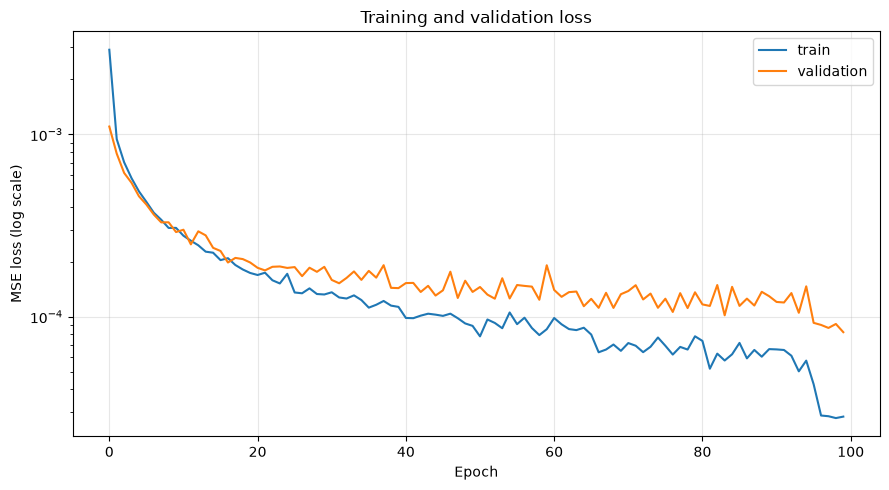

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.yscale("log")
plt.xlabel("Epoch"); plt.ylabel("MSE loss (log scale)")
plt.title("Training and validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
# 5. Evaluation

Three checks, in order of importance:
1. **Accuracy** — MAE / RMSE / max error vs BS02 on a held-out test set.
2. **Speed** — network batch inference vs BS02 sequential evaluation.
3. **Arbitrage-free constraint** — price must increase with volatility ($\partial P/\partial\sigma > 0$). A model that violates this is financially wrong even if its MSE is low.

In [11]:
# Accuracy on held-out test set.
X_test = torch.tensor(test_data["inputs"], dtype=torch.float32)
X_test_n = (X_test - mean) / std
y_test = test_data["targets"]

model.eval()
t0 = time.time()
with torch.no_grad():
    y_pred = model(X_test_n).numpy()
nn_time = time.time() - t0

errors = np.abs(y_pred - y_test)
print("Accuracy on held-out test set:")
print(f"  MAE:        {errors.mean():.6f}")
print(f"  RMSE:       {np.sqrt(((y_pred - y_test)**2).mean()):.6f}")
print(f"  Max error:  {errors.max():.6f}")
print(f"  (errors are in price/K units; 0.001 = 0.1% of strike)")

Accuracy on held-out test set:
  MAE:        0.003117
  RMSE:       0.008530
  Max error:  0.147484
  (errors are in price/K units; 0.001 = 0.1% of strike)


In [12]:
# Speed comparison: batched NN vs sequential BS02.
n = len(y_test)
t0 = time.time()
for i in range(min(1000, n)):
    m, T, r, sigma, q = test_data["inputs"][i]
    american_put_bs02(m*100, 100, T, r, sigma, q)
bs02_time = (time.time() - t0) / min(1000, n) * n

print(f"NN inference ({n} samples):   {nn_time*1000:.1f} ms")
print(f"BS02 sequential ({n} samples): {bs02_time*1000:.1f} ms")
print(f"Speedup: {bs02_time/nn_time:.0f}x")

NN inference (8192 samples):   19.4 ms
BS02 sequential (8192 samples): 9085.4 ms
Speedup: 469x


### Prediction vs truth (the headline plot)
Points should hug the diagonal — the network's prices match BS02.

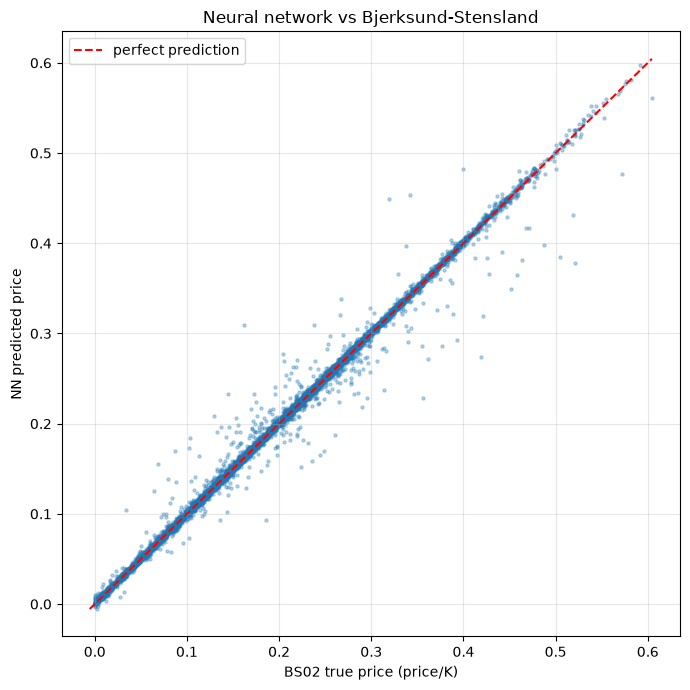

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("BS02 true price (price/K)")
plt.ylabel("NN predicted price")
plt.title("Neural network vs Bjerksund-Stensland")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Arbitrage-free check: monotonicity in volatility

Fix every input except $\sigma$, sweep $\sigma$ from 10% to 60%, and verify the predicted price only ever **increases**. A violation would mean the network produces theoretical arbitrage.

Price monotonically increasing in sigma: True


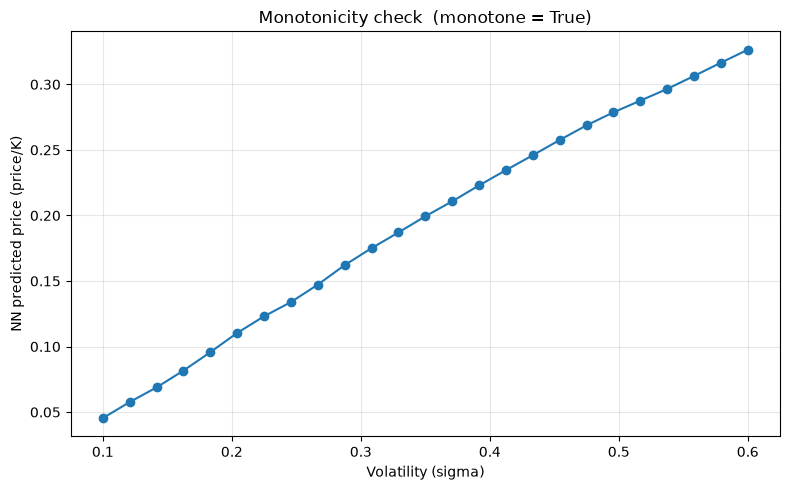

In [14]:
base = torch.tensor([[1.0, 1.0, 0.05, 0.30, 0.02]], dtype=torch.float32)  # m,T,r,sigma,q
sigmas = np.linspace(0.10, 0.60, 25)
prices_vs_sigma = []
for sig in sigmas:
    x = base.clone(); x[0, 3] = sig
    with torch.no_grad():
        prices_vs_sigma.append(model((x - mean) / std).item())

is_monotone = all(prices_vs_sigma[i] <= prices_vs_sigma[i+1] + 1e-6
                  for i in range(len(prices_vs_sigma)-1))
print(f"Price monotonically increasing in sigma: {is_monotone}")

plt.figure(figsize=(8, 5))
plt.plot(sigmas, prices_vs_sigma, "o-")
plt.xlabel("Volatility (sigma)"); plt.ylabel("NN predicted price (price/K)")
plt.title(f"Monotonicity check  (monotone = {is_monotone})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()